<a href="https://colab.research.google.com/github/syedam1104-stack/ML-AI-Intership-/blob/main/WEEK_5_Tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1: K-Nearest Neighbors from Scratch

In [1]:
import numpy as np
from collections import Counter

def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return predictions

    def _predict(self, x):
        # 1. Distance calculate
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]
        # 2. K nearest neighbors
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        # 3. Majority vote
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

# Test
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X, y = load_iris().data, load_iris().target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

knn = KNN(k=5)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)
print("KNN Accuracy:", np.mean(pred == y_test))

KNN Accuracy: 0.9333333333333333


Task 2: Decision Tree + Visualization

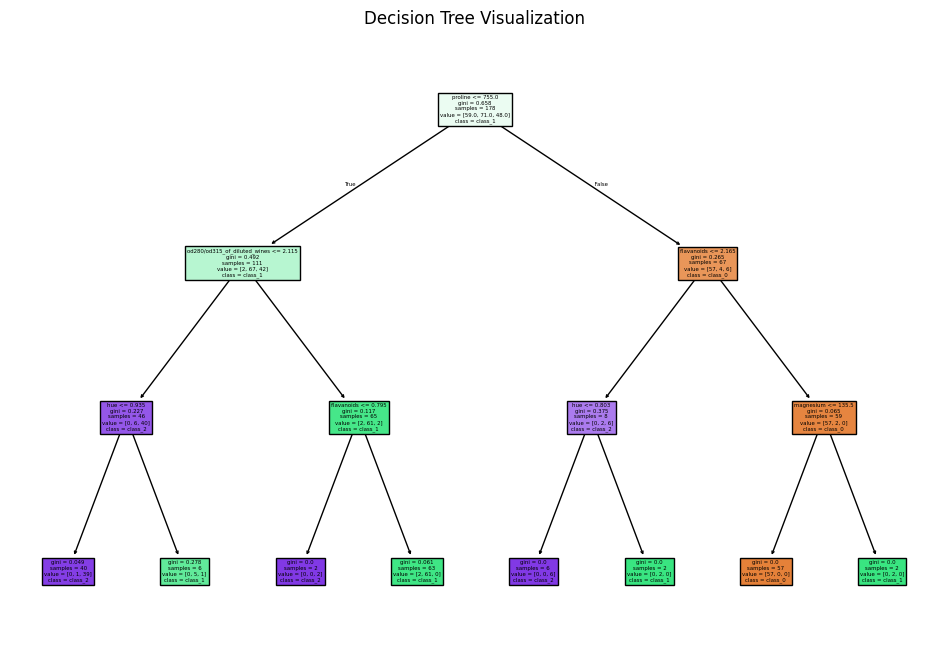

In [2]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt

# Data
data = load_wine()
X, y = data.data, data.target

# Model
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X, y)

# Tree plot karo
plt.figure(figsize=(12,8))
plot_tree(clf, filled=True, feature_names=data.feature_names, class_names=data.target_names)
plt.title("Decision Tree Visualization")
plt.show()

Task 3: Random Forest + Feature Importance

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
X, y = data.data, data.target

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

print("Random Forest Accuracy:", rf.score(X, y))

# Feature Importance
importances = pd.DataFrame({
    'Feature': data.feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(importances.head(10))

Random Forest Accuracy: 1.0
                 Feature  Importance
23            worst area    0.139357
27  worst concave points    0.132225
7    mean concave points    0.107046
20          worst radius    0.082848
22       worst perimeter    0.080850
2         mean perimeter    0.067990
6         mean concavity    0.066917
3              mean area    0.060462
26       worst concavity    0.037339
0            mean radius    0.034843


Task 4: K-Means from Scratch + Elbow Method

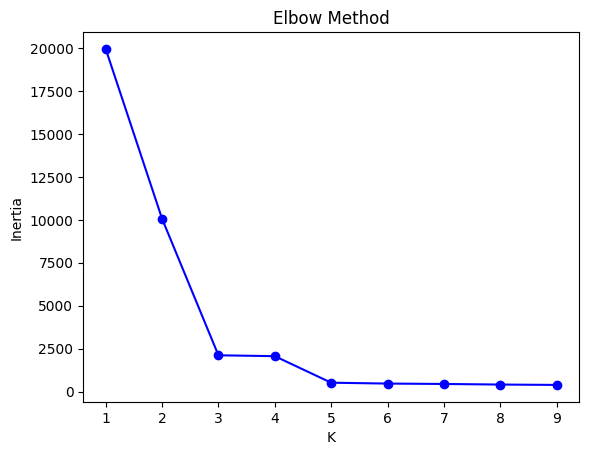

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Sample 2D data
X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

class KMeans:
    def __init__(self, k=3, max_iters=100):
        self.k = k
        self.max_iters = max_iters

    def fit(self, X):
        # Random centroids
        self.centroids = X[np.random.choice(X.shape[0], self.k, replace=False)]

        for _ in range(self.max_iters):
            # Assign clusters
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            self.labels = np.argmin(distances, axis=1)

            # Update centroids
            new_centroids = np.array([X[self.labels == i].mean(axis=0) for i in range(self.k)])

            if np.all(self.centroids == new_centroids):
                break
            self.centroids = new_centroids

    def predict(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

# Elbow Method
inertias = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(k=k)
    kmeans.fit(X)
    inertia = np.sum([np.min(np.linalg.norm(X[:, np.newaxis] - kmeans.centroids, axis=2), axis=1)**2])
    inertias.append(inertia)

plt.plot(K_range, inertias, 'bo-')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

Task 5: DBSCAN vs K-Means Compare

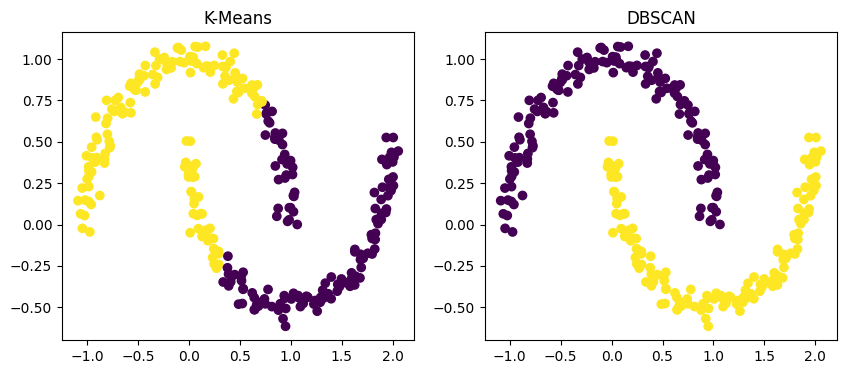

In [5]:
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_moons

# Moon shaped data
X, _ = make_moons(n_samples=300, noise=0.05)

# KMeans
kmeans = KMeans(n_clusters=2).fit(X)
k_labels = kmeans.labels_

# DBSCAN
dbscan = DBSCAN(eps=0.3)
db_labels = dbscan.fit_predict(X)

# Plot compare
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].scatter(X[:,0], X[:,1], c=k_labels, cmap='viridis')
ax[0].set_title('K-Means')
ax[1].scatter(X[:,0], X[:,1], c=db_labels, cmap='viridis')
ax[1].set_title('DBSCAN')
plt.show()

Task 6: K-Fold Cross Validation

In [7]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
import numpy as np

# Load a consistent dataset for cross-validation
data = load_breast_cancer()
X, y = data.data, data.target

model = RandomForestClassifier(n_estimators=50, random_state=42)

# 5-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=kf)

print("CV Scores:", scores)
print("Mean Accuracy:", np.mean(scores))
print("Std Dev:", np.std(scores))

CV Scores: [0.95614035 0.96491228 0.93859649 0.96491228 0.96460177]
Mean Accuracy: 0.9578326346840551
Std Dev: 0.010187806503281693


Week 5 Mini Project: Customer Segmentation

In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Example: Study habits data
data = {
    'Study_Hours': [2,5,1,8,4,9,3,7],
    'Quiz_Score': [40,70,30,90,60,95,50,85]
}
df = pd.DataFrame(data)

# 1. Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 2. KMeans Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 3. Cluster Profile
for i in range(3):
    cluster_data = df[df['Cluster']==i]
    print(f"\nCluster {i} Profile:")
    print(f"Avg Study Hours: {cluster_data['Study_Hours'].mean():.1f}")
    print(f"Avg Quiz Score: {cluster_data['Quiz_Score'].mean():.1f}")

print("\nFinal Data with Clusters:")
print(df)


Cluster 0 Profile:
Avg Study Hours: 2.0
Avg Quiz Score: 40.0

Cluster 1 Profile:
Avg Study Hours: 8.0
Avg Quiz Score: 90.0

Cluster 2 Profile:
Avg Study Hours: 4.5
Avg Quiz Score: 65.0

Final Data with Clusters:
   Study_Hours  Quiz_Score  Cluster
0            2          40        0
1            5          70        2
2            1          30        0
3            8          90        1
4            4          60        2
5            9          95        1
6            3          50        0
7            7          85        1
